In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/used_cars_featured.csv")

In [2]:
# 빠른 테스트용 샘플
df_sample = df.sample(n=200000, random_state=42)

print(df_sample.shape)

(200000, 22)


In [3]:
from catboost import CatBoostRegressor

print("CatBoost 설치 성공!")


CatBoost 설치 성공!


In [4]:
model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=50
)

In [5]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

NameError: name 'X_train' is not defined

In [6]:
features = [
    "make_name",
    "model_name",
    "year",
    "vehicle_age",
    "mileage",
    "mileage_per_year",
    "body_type",
    "fuel_type",
    "transmission",
    "engine_displacement",
    "engine_cylinders",
    "engine_type",
    "wheel_system",
    "has_accidents",
    "frame_damaged",
    "city_fuel_economy",
    "highway_fuel_economy",
    "is_large_engine"
]

X = df_sample[features]
y = df_sample["price"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(160000, 18)
(40000, 18)


In [9]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=8,
    random_seed=42,
    verbose=50
)

In [11]:
cat_features = [
    "make_name",
    "model_name",
    "body_type",
    "fuel_type",
    "transmission",
    "engine_cylinders",
    "engine_type",
    "wheel_system",
    "has_accidents",
    "frame_damaged",
    "is_large_engine"
]

In [12]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 18893.9304824	total: 276ms	remaining: 54.9s
50:	learn: 8338.3668829	total: 7.39s	remaining: 21.6s
100:	learn: 7353.1820522	total: 13.9s	remaining: 13.7s
150:	learn: 6617.6796145	total: 20.7s	remaining: 6.7s
199:	learn: 6190.7871031	total: 27.5s	remaining: 0us


CatBoostRegressor(depth=8, iterations=200, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=50)

In [13]:
pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² : {r2:.4f}")

MAE : 3,725.35
RMSE : 14,040.61
R² : 0.6105


In [15]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
0,make_name,22.482251
4,mileage,14.570098
1,model_name,9.595736
6,body_type,9.388300
9,engine_displacement,8.426419
3,vehicle_age,6.979447
10,engine_cylinders,5.860757
11,engine_type,5.210825
12,wheel_system,4.329284
5,mileage_per_year,3.268737


In [16]:
df_sample["price"].describe()

count    2.000000e+05
mean     2.994464e+04
std      2.054757e+04
min      2.500000e+02
25%      1.841500e+04
50%      2.645500e+04
75%      3.822625e+04
max      2.738900e+06
Name: price, dtype: float64

In [17]:
df_sample["price"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     50525.000
0.950     59767.150
0.990     84050.300
0.995    102740.075
0.999    178880.120
Name: price, dtype: float64

In [18]:
df_filtered = df_sample[df_sample["price"] <= 84050.3].copy()

print(df_filtered.shape)

(198000, 22)


In [19]:
X = df_filtered[features]
y = df_filtered["price"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

In [22]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 14403.5653408	test: 14380.8220408	best: 14380.8220408 (0)	total: 170ms	remaining: 1m 25s
100:	learn: 5075.6631289	test: 5075.1224455	best: 5075.1224455 (100)	total: 16.3s	remaining: 1m 4s
200:	learn: 4589.6770362	test: 4602.4887762	best: 4602.4887762 (200)	total: 32.9s	remaining: 49s
300:	learn: 4365.5673683	test: 4394.9461642	best: 4394.9461642 (300)	total: 49.4s	remaining: 32.7s
400:	learn: 4217.4657523	test: 4264.0974919	best: 4264.0974919 (400)	total: 1m 5s	remaining: 16.3s
499:	learn: 4120.7335180	test: 4181.4417482	best: 4181.4417482 (499)	total: 1m 22s	remaining: 0us

bestTest = 4181.441748
bestIteration = 499



CatBoostRegressor(depth=8, early_stopping_rounds=50, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [23]:
pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² : {r2:.4f}")

MAE : 2,924.60
RMSE : 4,181.44
R² : 0.9214


📊 이제부터는 실험 기록을 남깁시다.

노트북 마지막에 이런 표를 만들어 두세요.

모델	데이터	설정	MAE	RMSE	R²
Baseline	전체	기본 CatBoost	3,725	14,040	0.6105
Experiment 1	상위 1% 제거	Early Stopping	?	?	?

이 표는 나중에 README에도 그대로 넣을 수 있고, "모델을 만들었다"가 아니라 "실험하고 개선했다"는 점을 보여주는 좋은 자료가 됩니다.

🚀 이제 학습을 돌려보시고, 새로운 MAE, RMSE, R² 결과를 알려주세요. 그 결과를 보고 다음 실험(로그 변환이 좋을지, 하이퍼파라미터를 더 조정할지)을 함께 결정해 보겠습니다.

In [24]:
model.save_model("../models/catboost_final.cbm")

In [25]:
import shap

c:\01Developkits\miniconda3\envs\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
explainer = shap.TreeExplainer(model)

In [27]:
sample = X_test.iloc[[0]]

In [28]:
shap_values = explainer(sample)

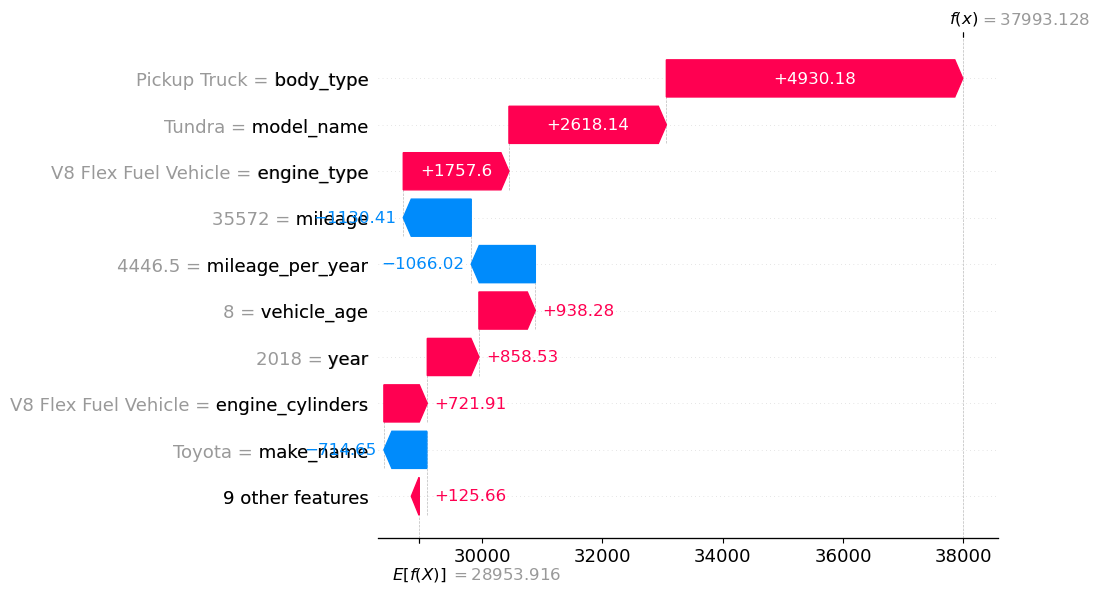

In [29]:
shap.plots.waterfall(shap_values[0])

In [30]:
model.save_model("../models/catboost_final.cbm")

In [31]:
import json

brand_model = (
    df[["make_name", "model_name"]]
    .drop_duplicates()
    .sort_values(["make_name", "model_name"])
)

brand_dict = {}

for make, group in brand_model.groupby("make_name"):
    brand_dict[make] = sorted(group["model_name"].unique().tolist())

with open("../data/brand_model.json", "w", encoding="utf-8") as f:
    json.dump(brand_dict, f, indent=4)

In [32]:
import json

features = [
    "fuel_type",
    "transmission",
    "body_type",
    "engine_displacement",
    "engine_cylinders",
    "engine_type",
    "wheel_system"
]

vehicle_info = {}

for (make, model), group in df.groupby(["make_name", "model_name"]):

    vehicle_info.setdefault(make, {})

    info = {}

    for col in features:

        mode = group[col].mode()

        if len(mode) > 0:
            value = mode.iloc[0]

            # numpy 타입을 일반 Python 타입으로 변환
            if hasattr(value, "item"):
                value = value.item()

            info[col] = value

    vehicle_info[make][model] = info

with open("../data/vehicle_info.json", "w", encoding="utf-8") as f:
    json.dump(vehicle_info, f, indent=4)